# Window-level AMPness along parent sequences

Plot per-window P(AMP) along each parent sequence.

**Inputs** (set `COMPARISON_CSV` in the first code cell):

- **`model_comparison_windowed_latest.csv`** from `compare_model_predictions_windowed.py` (already has `parent_id`, `start`, `length`; SVM-only or GNN). No merge needed.
- **Legacy**: parent-level `model_comparison_latest.csv` + **`window_map.csv`** from the pipeline windowing step. The loader joins on `peptide_id`, normalized ids (`SEQ_1` ↔ `seq_1`), or `seqIndex`.

- **Layout**: three separate figures — (1) line/scatter, (2) mean-per-residue histogram bars, (3) max-per-residue histogram bars.
- **Line panel**: scatter at window center; line = per-residue mean P(AMP).
- **Mean bar panel**: histogram-style bars; height = mean P(AMP) over covering windows.
- **Max bar panel**: same style; height = max P(AMP) over covering windows.

If `window_map.csv` is missing for a legacy run, re-run pipeline windowing or the `SYNTH_IF_MISSING` cell.

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def repo_root_from_here() -> Path:
    here = Path.cwd().resolve()
    for p in (here, *here.parents):
        if (p / "sequence_to_svm_minimal").is_dir():
            return p
    return here


ROOT = repo_root_from_here()

# --- edit these paths if needed ---
COMPARISON_CSV = ROOT / "sequence_to_svm_minimal/data/test/SRC/window_25-35/generated/model_comparison_windowed_latest.csv"
WINDOW_MAP_CSV = ROOT / "sequence_to_svm_minimal/data/test/SRC/window_25-35/generated/inputs/window_map.csv"

# Models to plot (columns ending with _prob_AMP). None = every model.
PROB_COLUMN_SUBSTR: str | None = None  # e.g. "Geo" to restrict; None = all

MAX_PARENTS = 12  # max parent rows; None = all parents
FIGWIDTH_PER_MODEL = 4.0  # subplot width per model column (each figure)
FIGHEIGHT_PER_PARENT = 3.0  # subplot height per parent row
HEATMAP_CMAP = "viridis"

PLOT_MAIN_TITLE = "Predicted Antimicrobial Probability Across Parent Sequences"
PLOT_SUBTITLE = (
    "Figures: window line plot; mean-per-residue histogram; max-per-residue histogram."
)

print("ROOT:", ROOT)
print("comparison:", COMPARISON_CSV)
print("window_map:", WINDOW_MAP_CSV)

ROOT: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction
comparison: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\data\test\SRC\window_25-35\generated\model_comparison_windowed_latest.csv
window_map: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\data\test\SRC\window_25-35\generated\inputs\window_map.csv


In [2]:
import csv
import sys

# If the pipeline has not written `window_map.csv` yet, rebuild it from the same
# parent sequences + windowing parameters so `peptide_id` (SEQ_<n>) matches `canonical_seqs.txt`.
SYNTH_IF_MISSING = True
PARENTS_TXT = ROOT / "sequence_to_svm_minimal/data/test/H2A_homologues_windowed/H2AHomologues_Kyle.txt"
WINDOW_MIN_LEN, WINDOW_MAX_LEN, WINDOW_STRIDE = 20, 35, 1
WINDOW_MAP_FALLBACK = (
    ROOT
    / "sequence_to_svm_minimal/data/test/H2A_homologues_windowed/generated/inputs/window_map_notebook.csv"
)


def _parse_parent_records(path: Path) -> list[tuple[str, str]]:
    rows: list[tuple[str, str]] = []
    for raw in path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split(None, 1)
        if len(parts) == 2:
            rows.append((parts[0], parts[1].replace(" ", "")))
    return rows


if SYNTH_IF_MISSING and not WINDOW_MAP_CSV.is_file():
    sys.path.insert(0, str(ROOT / "sequence_to_svm_minimal"))
    from peptide_pipeline.windowing import expand_records_to_windows

    recs = _parse_parent_records(PARENTS_TXT)
    _, windows = expand_records_to_windows(
        recs,
        min_len=WINDOW_MIN_LEN,
        max_len=WINDOW_MAX_LEN,
        stride=WINDOW_STRIDE,
    )
    WINDOW_MAP_FALLBACK.parent.mkdir(parents=True, exist_ok=True)
    with open(WINDOW_MAP_FALLBACK, "w", newline="", encoding="utf-8") as wf:
        writer = csv.DictWriter(
            wf,
            fieldnames=[
                "seqIndex",
                "peptide_id",
                "window_id",
                "parent_id",
                "start",
                "length",
                "sequence",
            ],
        )
        writer.writeheader()
        for w in windows:
            writer.writerow(
                {
                    "seqIndex": w.seq_index,
                    "peptide_id": w.peptide_id,
                    "window_id": w.window_id,
                    "parent_id": w.parent_id,
                    "start": w.start,
                    "length": w.length,
                    "sequence": w.window_seq,
                }
            )
    WINDOW_MAP_CSV = WINDOW_MAP_FALLBACK
    print("Wrote synthetic window_map:", WINDOW_MAP_CSV, "| windows:", len(windows))
elif not WINDOW_MAP_CSV.is_file():
    print("window_map missing; set SYNTH_IF_MISSING = True or add window_map.csv")
else:
    print("Using window_map:", WINDOW_MAP_CSV)

Using window_map: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\data\test\SRC\window_25-35\generated\inputs\window_map.csv


In [3]:
SUFFIX = "_prob_AMP"
WINDOW_LAYOUT_COLS = frozenset({"parent_id", "start", "length"})


def pick_prob_columns(cols: list[str], substr: str | None) -> list[str]:
    out = sorted(c for c in cols if c.endswith(SUFFIX))
    if substr:
        out = [c for c in out if substr in c]
    return out


def _normalize_peptide_id(value: object) -> str:
    return str(value).strip().upper()


def _with_center(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["center"] = out["start"].astype(float) + out["length"].astype(float) / 2.0
    return out


def _merge_with_window_map(comp: pd.DataFrame, wmap: pd.DataFrame) -> pd.DataFrame:
    need = {"peptide_id", "parent_id", "start", "length"}
    miss = need - set(wmap.columns)
    if miss:
        raise ValueError(f"window_map.csv missing columns: {sorted(miss)}")

    extra = [c for c in ("window_id", "seqIndex") if c in wmap.columns]
    w_sub = wmap[list(need | set(extra))].copy()

    for on in ("peptide_id",):
        df = comp.merge(w_sub, on=on, how="inner", suffixes=("", "_map"))
        if not df.empty:
            return df

    comp_n = comp.copy()
    comp_n["_pid_norm"] = comp_n["peptide_id"].map(_normalize_peptide_id)
    w_n = w_sub.copy()
    w_n["_pid_norm"] = w_n["peptide_id"].map(_normalize_peptide_id)
    drop = [c for c in w_n.columns if c in comp_n.columns and c != "_pid_norm"]
    df = comp_n.merge(w_n.drop(columns=drop, errors="ignore"), on="_pid_norm", how="inner")
    if not df.empty:
        return df.drop(columns=["_pid_norm"], errors="ignore")

    if "seqIndex" in comp.columns and "seqIndex" in w_sub.columns:
        idx_cols = ["seqIndex", "parent_id", "start", "length", *extra]
        df = comp.merge(w_sub[idx_cols].drop_duplicates("seqIndex"), on="seqIndex", how="inner")
        if not df.empty:
            return df

    raise ValueError(
        "Merge produced 0 rows: check peptide_id / seqIndex alignment between comparison CSV and window_map."
    )


def load_merged(comparison_csv: Path, window_map_csv: Path | None = None) -> pd.DataFrame:
    """Load per-window predictions with parent layout columns for plotting."""
    if not comparison_csv.is_file():
        raise FileNotFoundError(f"comparison CSV not found: {comparison_csv}")

    comp = pd.read_csv(comparison_csv)
    if WINDOW_LAYOUT_COLS.issubset(comp.columns):
        df = comp.copy()
        if "window_id" not in df.columns and window_map_csv and window_map_csv.is_file():
            wmap = pd.read_csv(window_map_csv)
            keys = [c for c in ("peptide_id", "seqIndex") if c in df.columns and c in wmap.columns]
            if keys:
                extra = [c for c in ("window_id",) if c in wmap.columns]
                df = df.merge(wmap[keys + extra].drop_duplicates(keys[0]), on=keys[0], how="left")
        return _with_center(df)

    if window_map_csv is None or not window_map_csv.is_file():
        raise FileNotFoundError(
            "Comparison CSV has no parent_id/start/length columns. "
            "Point COMPARISON_CSV at model_comparison_windowed_latest.csv, "
            "or provide window_map.csv from the pipeline windowing step."
        )
    wmap = pd.read_csv(window_map_csv)
    return _with_center(_merge_with_window_map(comp, wmap))


def load_windowed_sequence_df(comparison_csv: Path) -> pd.DataFrame:
    """Alias for windowed exports from compare_model_predictions_windowed.py."""
    return load_merged(comparison_csv, window_map_csv=None)


def mean_prob_along_parent(parent_df: pd.DataFrame, prob_col: str, parent_len: int) -> np.ndarray:
    pos_sum = np.zeros(parent_len, dtype=np.float64)
    pos_count = np.zeros(parent_len, dtype=np.float64)
    for _, r in parent_df.iterrows():
        s = int(r["start"])
        L = int(r["length"])
        v = float(r[prob_col])
        if not math.isfinite(v):
            continue
        lo, hi = max(0, s), min(parent_len, s + L)
        if lo < hi:
            pos_sum[lo:hi] += v
            pos_count[lo:hi] += 1.0
    out = np.full(parent_len, np.nan, dtype=np.float64)
    covered = pos_count > 0
    out[covered] = pos_sum[covered] / pos_count[covered]
    return out


def max_prob_along_parent(parent_df: pd.DataFrame, prob_col: str, parent_len: int) -> np.ndarray:
    pos = np.zeros(parent_len, dtype=np.float64)
    covered = np.zeros(parent_len, dtype=bool)
    for _, r in parent_df.iterrows():
        s = int(r["start"])
        L = int(r["length"])
        v = float(r[prob_col])
        if not math.isfinite(v):
            continue
        lo, hi = max(0, s), min(parent_len, s + L)
        if lo < hi:
            pos[lo:hi] = np.maximum(pos[lo:hi], v)
            covered[lo:hi] = True
    out = np.full(parent_len, np.nan, dtype=np.float64)
    out[covered] = pos[covered]
    return out


def _draw_residue_histogram(
    ax,
    x_idx: np.ndarray,
    profile: np.ndarray,
    parent_len: int,
    cmap,
    norm,
) -> None:
    heights = np.where(np.isfinite(profile), profile, 0.0)
    bar_colors = [
        cmap(norm(v)) if np.isfinite(v) else (0.85, 0.85, 0.85, 1.0)
        for v in profile
    ]
    ax.bar(
        x_idx,
        heights,
        width=1.0,
        color=bar_colors,
        align="edge",
        linewidth=0,
        edgecolor="none",
    )
    ax.set_xlim(0, parent_len)
    ax.set_ylim(0, 1)


def plot_ampness_panels(
    df: pd.DataFrame,
    prob_cols: list[str],
    *,
    max_parents: int | None = 12,
    figwidth_per_model: float = 4.0,
    figheight_per_parent: float = 3.0,
    heatmap_cmap: str = "viridis",
    main_title: str = "",
    subtitle: str = "",  # unused; kept for backward compatibility with callers
) -> None:
    """Print three figures: line/scatter, mean-per-residue bars, max-per-residue bars."""
    parents = sorted(df["parent_id"].astype(str).unique())
    if max_parents is not None:
        parents = parents[:max_parents]
    if not parents:
        print("No parent_id values to plot.")
        return
    if not prob_cols:
        print("No probability columns to plot.")
        return

    prob_cols = list(reversed(prob_cols))
    n_p, n_m = len(parents), len(prob_cols)
    fig_w = max(6.0, figwidth_per_model * n_m)
    fig_h = max(3.5, figheight_per_parent * n_p)
    cmap = plt.get_cmap(heatmap_cmap)
    norm = plt.Normalize(vmin=0.0, vmax=1.0)

    fig_line, axes_line = plt.subplots(
        n_p,
        n_m,
        figsize=(fig_w, fig_h),
        sharex="col",
        sharey="row",
        squeeze=False,
        layout="constrained",
    )
    axes_line = np.atleast_2d(np.asarray(axes_line, dtype=object))

    fig_bar, axes_bar = plt.subplots(
        n_p,
        n_m,
        figsize=(fig_w, fig_h),
        sharex="col",
        sharey="row",
        squeeze=False,
        layout="constrained",
    )
    axes_bar = np.atleast_2d(np.asarray(axes_bar, dtype=object))

    fig_max, axes_max = plt.subplots(
        n_p,
        n_m,
        figsize=(fig_w, fig_h),
        sharex="col",
        sharey="row",
        squeeze=False,
        layout="constrained",
    )
    axes_max = np.atleast_2d(np.asarray(axes_max, dtype=object))

    for i, pid in enumerate(parents):
        sub = df[df["parent_id"].astype(str) == pid].sort_values(["start", "length"])
        parent_len = int((sub["start"] + sub["length"]).max())
        x_idx = np.arange(parent_len)

        for j, pc in enumerate(prob_cols):
            label = pc[: -len(SUFFIX)]
            color = f"C{j}"
            profile_mean = mean_prob_along_parent(sub, pc, parent_len)
            profile_max = max_prob_along_parent(sub, pc, parent_len)

            ax_line = axes_line[i, j]
            ax_line.scatter(sub["center"], sub[pc], s=10, alpha=0.8, color=color)
            ax_line.plot(x_idx, profile_mean, linewidth=1.6, alpha=0.95, color=color)
            ax_line.set_ylim(-0.02, 1.02)
            ax_line.set_xlim(0, parent_len)
            if i == 0:
                ax_line.set_title(label)
            if j == 0:
                ax_line.set_ylabel("P(AMP)")
            if j == n_m - 1:
                ax2 = ax_line.twinx()
                ax2.set_ylabel(pid, rotation=270, labelpad=14)
                ax2.set_yticks([])
            if i == n_p - 1:
                ax_line.set_xlabel("Residue index (0-based)")

            ax_bar = axes_bar[i, j]
            _draw_residue_histogram(ax_bar, x_idx, profile_mean, parent_len, cmap, norm)
            if i == 0:
                ax_bar.set_title(label)
            if j == 0:
                ax_bar.set_ylabel("P(AMP)")
            if j == n_m - 1:
                ax2 = ax_bar.twinx()
                ax2.set_ylabel(pid, rotation=270, labelpad=14)
                ax2.set_yticks([])
            if i == n_p - 1:
                ax_bar.set_xlabel("Residue index (0-based)")
                sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
                sm.set_array([])
                fig_bar.colorbar(sm, ax=ax_bar, fraction=0.046, pad=0.04, label="P(AMP)")

            ax_max = axes_max[i, j]
            _draw_residue_histogram(ax_max, x_idx, profile_max, parent_len, cmap, norm)
            if i == 0:
                ax_max.set_title(label)
            if j == 0:
                ax_max.set_ylabel("P(AMP)")
            if j == n_m - 1:
                ax2 = ax_max.twinx()
                ax2.set_ylabel(pid, rotation=270, labelpad=14)
                ax2.set_yticks([])
            if i == n_p - 1:
                ax_max.set_xlabel("Residue index (0-based)")
                sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
                sm.set_array([])
                fig_max.colorbar(sm, ax=ax_max, fraction=0.046, pad=0.04, label="P(AMP)")

    if main_title:
        fig_line.suptitle(main_title)
        fig_bar.suptitle(f"{main_title} — mean per residue")
        fig_max.suptitle(f"{main_title} — max per residue")
    plt.show()
    plt.show()
    plt.show()

merged rows: 5577 | parents: 1
plotting: ['SVM_prob_AMP']


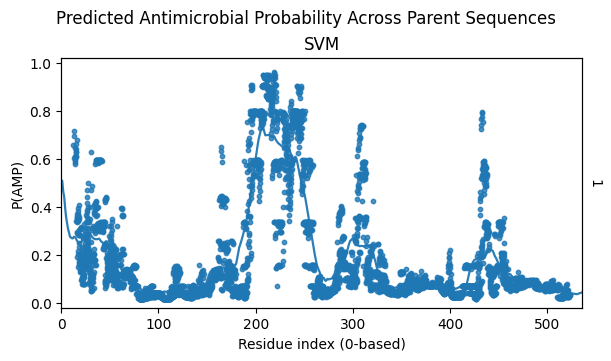

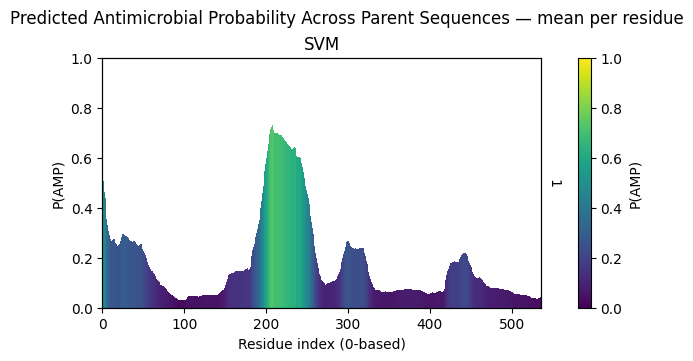

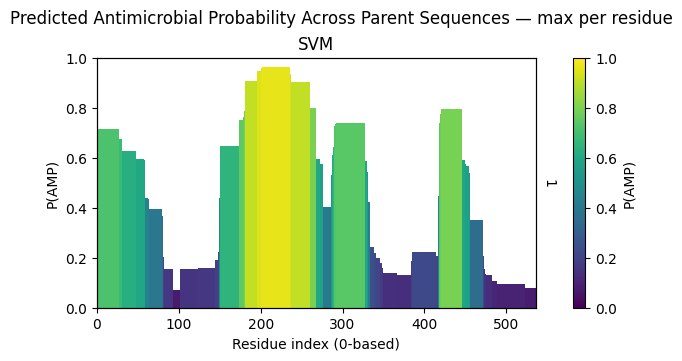

In [4]:
df = load_merged(COMPARISON_CSV, WINDOW_MAP_CSV)
prob_cols = pick_prob_columns(list(df.columns), PROB_COLUMN_SUBSTR)
if not prob_cols:
    raise ValueError(f"No prob columns matching suffix {SUFFIX!r} and substr={PROB_COLUMN_SUBSTR!r}")

for pc in prob_cols:
    n_finite = int(pd.to_numeric(df[pc], errors="coerce").notna().sum())
    if n_finite == 0:
        print(f"Warning: {pc} has no scores — re-run compare_model_predictions_windowed.py (or full pipeline for GNN columns).")

print("merged rows:", len(df), "| parents:", df["parent_id"].nunique())
print("plotting:", prob_cols)

plot_ampness_panels(
    df,
    prob_cols,
    max_parents=MAX_PARENTS,
    figwidth_per_model=FIGWIDTH_PER_MODEL,
    figheight_per_parent=FIGHEIGHT_PER_PARENT,
    heatmap_cmap=HEATMAP_CMAP,
    main_title=PLOT_MAIN_TITLE,
    subtitle=PLOT_SUBTITLE,
)

In [5]:
def max_score_along_parent(parent_df: pd.DataFrame, score_col: str, parent_len: int) -> np.ndarray:
    pos = np.full(parent_len, -np.inf, dtype=np.float64)
    covered = np.zeros(parent_len, dtype=bool)
    for _, r in parent_df.iterrows():
        s = int(r["start"])
        L = int(r["length"])
        v = float(r[score_col])
        if not math.isfinite(v):
            continue
        lo, hi = max(0, s), min(parent_len, s + L)
        if lo < hi:
            pos[lo:hi] = np.maximum(pos[lo:hi], v)
            covered[lo:hi] = True
    out = np.full(parent_len, np.nan, dtype=np.float64)
    out[covered] = pos[covered]
    return out

def _draw_residue_score_histogram(
    ax,
    x_idx: np.ndarray,
    profile: np.ndarray,
    parent_len: int,
    cmap,
    norm,
) -> None:
    heights = np.where(np.isfinite(profile), profile, 0.0)
    bar_colors = [
        cmap(norm(v)) if np.isfinite(v) else (0.85, 0.85, 0.85, 1.0)
        for v in profile
    ]
    ax.bar(
        x_idx,
        heights,
        width=1.0,
        color=bar_colors,
        align="edge",
        linewidth=0,
        edgecolor="none",
    )
    ax.set_xlim(0, parent_len)
    
    # Dynamic y-limits for scores
    valid_heights = heights[np.isfinite(profile)]
    if len(valid_heights) > 0:
        min_h, max_h = valid_heights.min(), valid_heights.max()
        # Add some padding
        padding = (max_h - min_h) * 0.1 if max_h > min_h else 0.5
        ax.set_ylim(min_h - padding, max_h + padding)
    else:
        ax.set_ylim(-3, 3)

def plot_sigma_panels(
    df: pd.DataFrame,
    score_cols: list[str],
    *,
    max_parents: int | None = 12,
    figwidth_per_model: float = 4.0,
    figheight_per_parent: float = 3.0,
    heatmap_cmap: str = "viridis",
    main_title: str = "",
    subtitle: str = "",
) -> None:
    """Print three figures: line/scatter, mean-per-residue bars, max-per-residue bars for sigma scores."""
    parents = sorted(df["parent_id"].astype(str).unique())
    if max_parents is not None:
        parents = parents[:max_parents]
    if not parents:
        print("No parent_id values to plot.")
        return
    if not score_cols:
        print("No score columns to plot.")
        return

    score_cols = list(reversed(score_cols))
    n_p, n_m = len(parents), len(score_cols)
    fig_w = max(6.0, figwidth_per_model * n_m)
    fig_h = max(3.5, figheight_per_parent * n_p)
    cmap = plt.get_cmap(heatmap_cmap)
    
    # Determine global min and max for normalization
    all_vals = df[score_cols].values.flatten()
    all_vals = all_vals[np.isfinite(all_vals)]
    if len(all_vals) > 0:
        vmin, vmax = all_vals.min(), all_vals.max()
        # Make it symmetric around 0 if it's a z-score
        abs_max = max(abs(vmin), abs(vmax))
        norm = plt.Normalize(vmin=-abs_max, vmax=abs_max)
    else:
        norm = plt.Normalize(vmin=-3.0, vmax=3.0)

    fig_line, axes_line = plt.subplots(
        n_p,
        n_m,
        figsize=(fig_w, fig_h),
        sharex="col",
        sharey="row",
        squeeze=False,
        layout="constrained",
    )
    axes_line = np.atleast_2d(np.asarray(axes_line, dtype=object))

    fig_bar, axes_bar = plt.subplots(
        n_p,
        n_m,
        figsize=(fig_w, fig_h),
        sharex="col",
        sharey="row",
        squeeze=False,
        layout="constrained",
    )
    axes_bar = np.atleast_2d(np.asarray(axes_bar, dtype=object))

    fig_max, axes_max = plt.subplots(
        n_p,
        n_m,
        figsize=(fig_w, fig_h),
        sharex="col",
        sharey="row",
        squeeze=False,
        layout="constrained",
    )
    axes_max = np.atleast_2d(np.asarray(axes_max, dtype=object))

    for i, pid in enumerate(parents):
        sub = df[df["parent_id"].astype(str) == pid].sort_values(["start", "length"])
        parent_len = int((sub["start"] + sub["length"]).max())
        x_idx = np.arange(parent_len)

        for j, sc in enumerate(score_cols):
            label = sc.replace("_score_z", "")
            color = f"C{j}"
            profile_mean = mean_prob_along_parent(sub, sc, parent_len)
            profile_max = max_score_along_parent(sub, sc, parent_len)

            ax_line = axes_line[i, j]
            ax_line.scatter(sub["center"], sub[sc], s=10, alpha=0.8, color=color)
            ax_line.plot(x_idx, profile_mean, linewidth=1.6, alpha=0.95, color=color)
            
            # Dynamic y-limits for line plot
            valid_vals = sub[sc].dropna()
            if len(valid_vals) > 0:
                min_v, max_v = valid_vals.min(), valid_vals.max()
                padding = (max_v - min_v) * 0.1 if max_v > min_v else 0.5
                ax_line.set_ylim(min_v - padding, max_v + padding)
            
            ax_line.set_xlim(0, parent_len)
            if i == 0:
                ax_line.set_title(label)
            if j == 0:
                ax_line.set_ylabel("Sigma Score")
            if j == n_m - 1:
                ax2 = ax_line.twinx()
                ax2.set_ylabel(pid, rotation=270, labelpad=14)
                ax2.set_yticks([])
            if i == n_p - 1:
                ax_line.set_xlabel("Residue index (0-based)")

            ax_bar = axes_bar[i, j]
            _draw_residue_score_histogram(ax_bar, x_idx, profile_mean, parent_len, cmap, norm)
            if i == 0:
                ax_bar.set_title(label)
            if j == 0:
                ax_bar.set_ylabel("Sigma Score")
            if j == n_m - 1:
                ax2 = ax_bar.twinx()
                ax2.set_ylabel(pid, rotation=270, labelpad=14)
                ax2.set_yticks([])
            if i == n_p - 1:
                ax_bar.set_xlabel("Residue index (0-based)")
                sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
                sm.set_array([])
                fig_bar.colorbar(sm, ax=ax_bar, fraction=0.046, pad=0.04, label="Sigma Score")

            ax_max = axes_max[i, j]
            _draw_residue_score_histogram(ax_max, x_idx, profile_max, parent_len, cmap, norm)
            if i == 0:
                ax_max.set_title(label)
            if j == 0:
                ax_max.set_ylabel("Sigma Score")
            if j == n_m - 1:
                ax2 = ax_max.twinx()
                ax2.set_ylabel(pid, rotation=270, labelpad=14)
                ax2.set_yticks([])
            if i == n_p - 1:
                ax_max.set_xlabel("Residue index (0-based)")
                sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
                sm.set_array([])
                fig_max.colorbar(sm, ax=ax_max, fraction=0.046, pad=0.04, label="Sigma Score")

    if main_title:
        fig_line.suptitle(main_title)
        fig_bar.suptitle(f"{main_title} — mean per residue")
        fig_max.suptitle(f"{main_title} — max per residue")
    plt.show()
    plt.show()
    plt.show()


plotting: ['SVM_score_z']


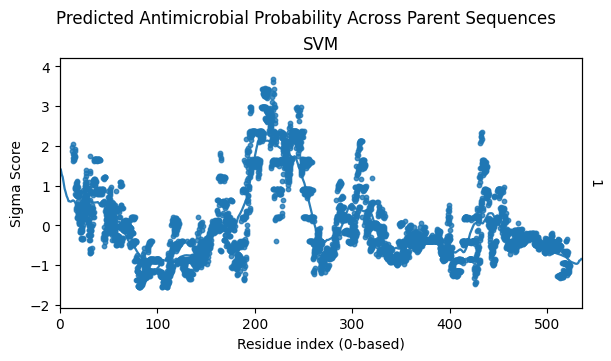

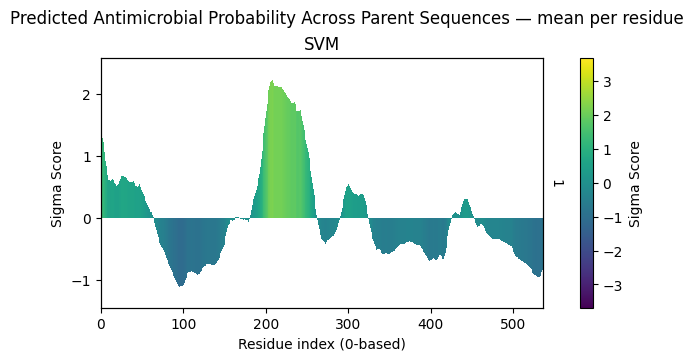

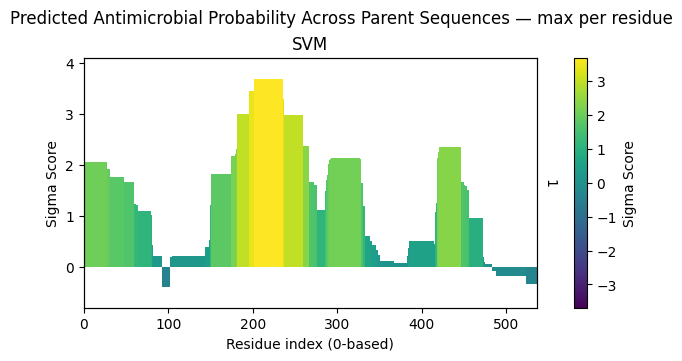

In [6]:
SCORE_SUFFIX = "_score_z"
score_cols = [c for c in df.columns if c.endswith(SCORE_SUFFIX)]
if PROB_COLUMN_SUBSTR:
    score_cols = [c for c in score_cols if PROB_COLUMN_SUBSTR in c]

if not score_cols:
    print(f"No score columns matching suffix {SCORE_SUFFIX!r} and substr={PROB_COLUMN_SUBSTR!r}")
else:
    for sc in score_cols:
        n_finite = int(pd.to_numeric(df[sc], errors="coerce").notna().sum())
        if n_finite == 0:
            print(f"Warning: {sc} has no scores.")

    print("plotting:", score_cols)

    plot_sigma_panels(
        df,
        score_cols,
        max_parents=MAX_PARENTS,
        figwidth_per_model=FIGWIDTH_PER_MODEL,
        figheight_per_parent=FIGHEIGHT_PER_PARENT,
        heatmap_cmap=HEATMAP_CMAP,
        main_title=PLOT_MAIN_TITLE.replace("P(AMP)", "Sigma Score") if PLOT_MAIN_TITLE else "",
        subtitle=PLOT_SUBTITLE,
    )
